# Summary 

This analyis compared three different machine learning models to predict the risk of
diabetes. By combining IterativeImputer to handle missing data and BorderlineSMOTE
to balance the dataset, all models achieved strong performance, with ROC-AUC
scores ranging from 0.82 to 0.86. 

 ## Models : XGBoost, Random Forest, and Logistic Regression. 

The best-performing model was implemented within a localized SQLite-based Clinical
Decision Support System (CDSS) for general practitioners. Risk stratification is driven by an algorithmic evaluation of high-impact features, utilizing cumulative percentage gain to categorize patients into low, moderate, or high- risk tiers. Despite its utility, the system is constrained by the underlying dataset, which lacks critical determinants such as biological sex and lifestyle factors. 

Consequently,this framework is designed to augment rather than replace clinical judgment; final diagnostic parameters must be calibrated in collaboration with healthcare
professionals to ensure alignment with established medical guidelines.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/nanditapore/healthcare-diabetes'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

from colorama import Style
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

/kaggle/input/datasets/nanditapore/healthcare-diabetes/Healthcare-Diabetes.csv


In [2]:
df_uncleaned = pd.read_csv('/kaggle/input/datasets/nanditapore/healthcare-diabetes/Healthcare-Diabetes.csv')
df_uncleaned

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
2763,2764,2,75,64,24,55,29.7,0.370,33,0
2764,2765,8,179,72,42,130,32.7,0.719,36,1
2765,2766,6,85,78,0,0,31.2,0.382,42,0
2766,2767,0,129,110,46,130,67.1,0.319,26,1


# Overview 

In [3]:
print("\n" + "="*50)
print("BASIC OVERVIEW".upper())
print("="*50)

print("\n DATAFRAME SHAPE:")
print(df_uncleaned.shape)

print("\n DATAFRAME INFO:")
df_uncleaned.info()

print("\n" + "="*50)
print("📈 SUMMARY STATISTICS".upper())
print("="*50)
print(df_uncleaned.describe(include='all'))

print("\n" + "="*50)
print("COLUMN NAMES".upper())
print("="*50)
print(df_uncleaned.columns.tolist())


df_uncleaned = df_uncleaned.drop(columns=['Id'])

initial_count = len(df_uncleaned)
duplicate_count = df_uncleaned.duplicated().sum()

df = df_uncleaned.drop_duplicates()
final_count = len(df)

print(f"Duplicates found: {duplicate_count}")
print(f"Rows before dropping duplicates: {initial_count}")
print(f"Rows after dropping duplicates: {final_count}")
print(f"Total rows removed: {initial_count - final_count}")

print ("Number of Duplicates") 
df_uncleaned.drop_duplicates()
df_uncleaned.info()
print( )
print("Number of Null")
df.isnull().sum()

total_rows = 2768
missing_zeros = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Zeros': (df == 0).sum()
})

missing_zeros['% Missing'] = (missing_zeros['Missing Values'] / total_rows * 100).round(2)
missing_zeros['% Zeros'] = (missing_zeros['Zeros'] / total_rows * 100).round(2)

print(missing_zeros)


BASIC OVERVIEW

 DATAFRAME SHAPE:
(2768, 10)

 DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB

📈 SUMMARY STATISTICS
                Id  Pregnancies      Glucose  BloodPressure  SkinThickness  \
count  2768.00000

# Descriptive Analysis and Visualisation

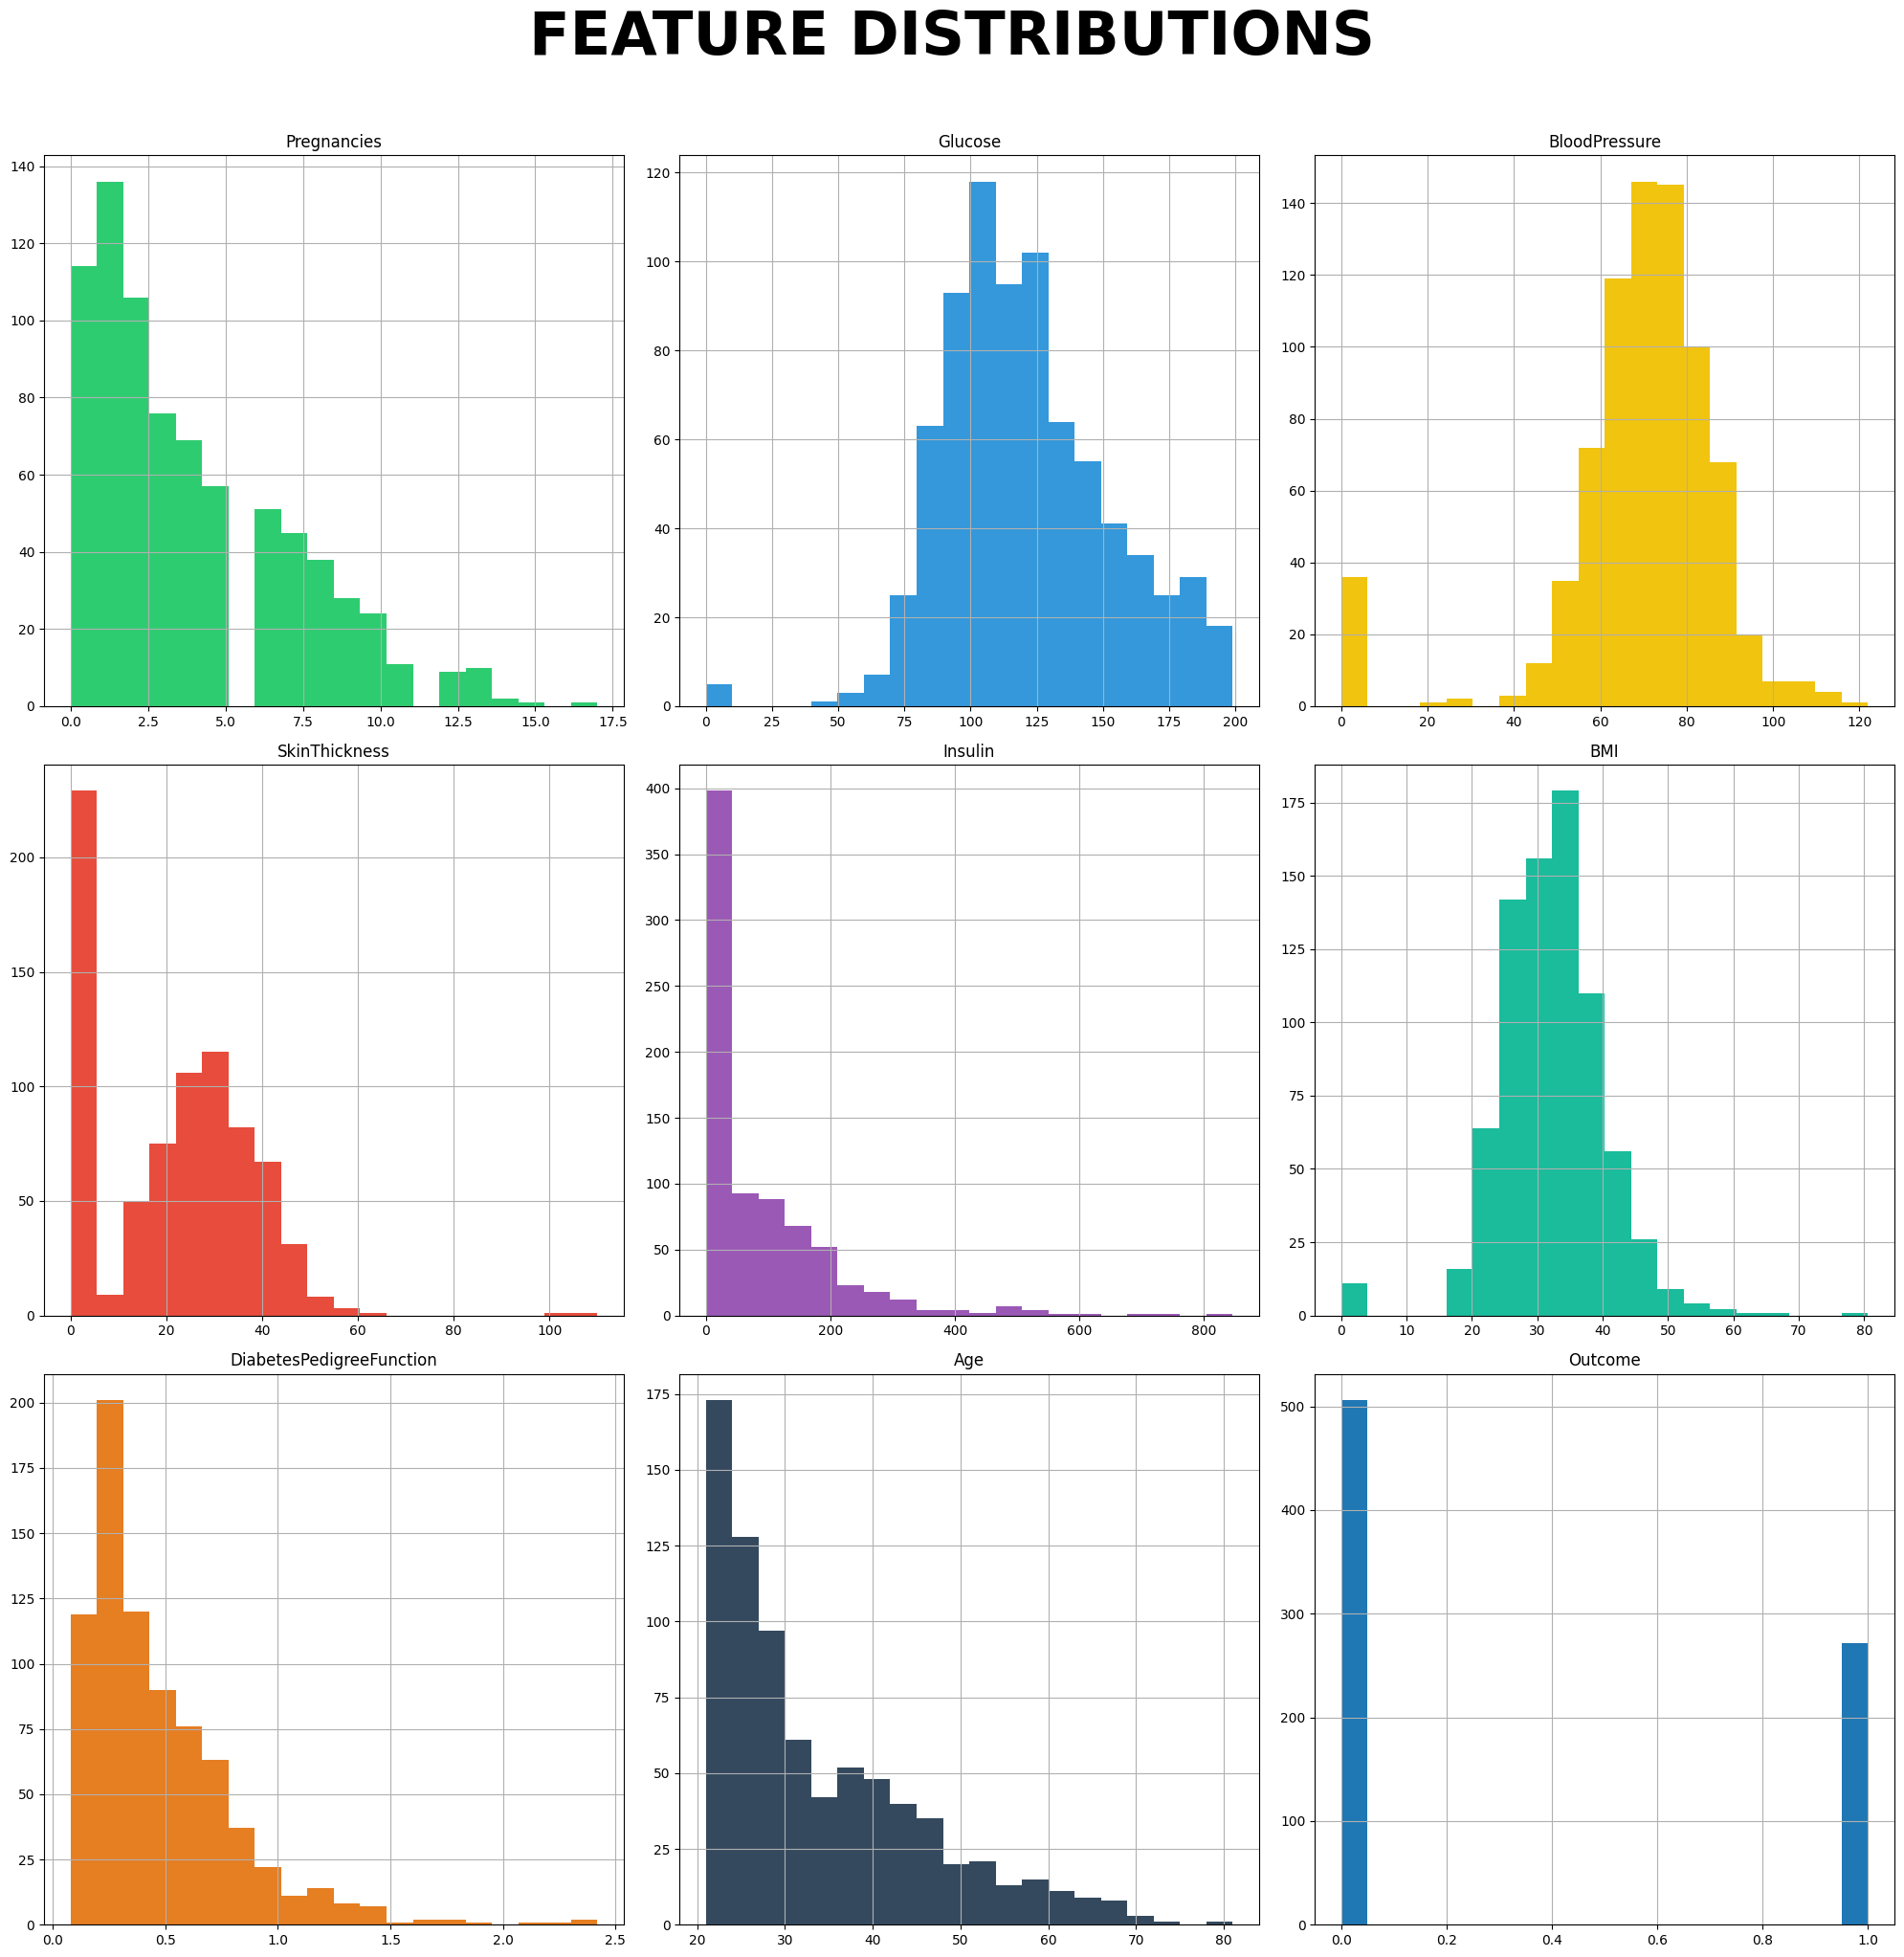

<Figure size 640x480 with 0 Axes>

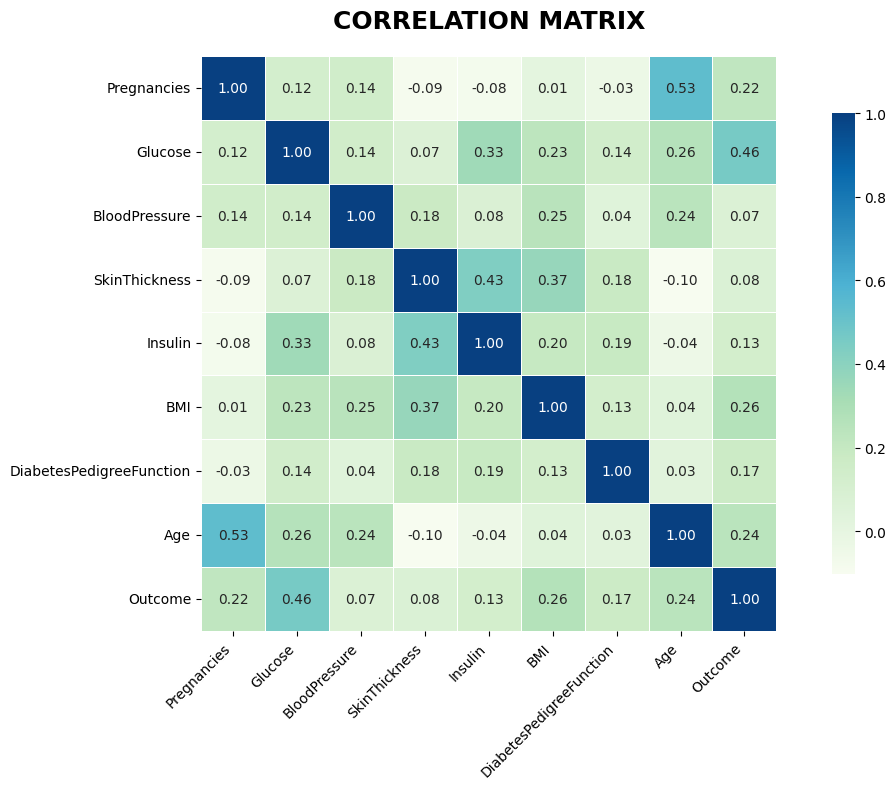

In [4]:
import matplotlib.pyplot as plt

colors = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

df.hist(figsize=(20,20), bins=20)

for ax, color in zip(plt.gcf().axes, colors):
    for patch in ax.patches:
        patch.set_facecolor(color)

plt.suptitle('FEATURE DISTRIBUTIONS', fontsize=45, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
for ax in plt.gcf().axes:
    ax.title.set_fontsize(12)
    ax.title.set_fontweight('bold')

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='GnBu', 
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('CORRELATION MATRIX', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Outliers 

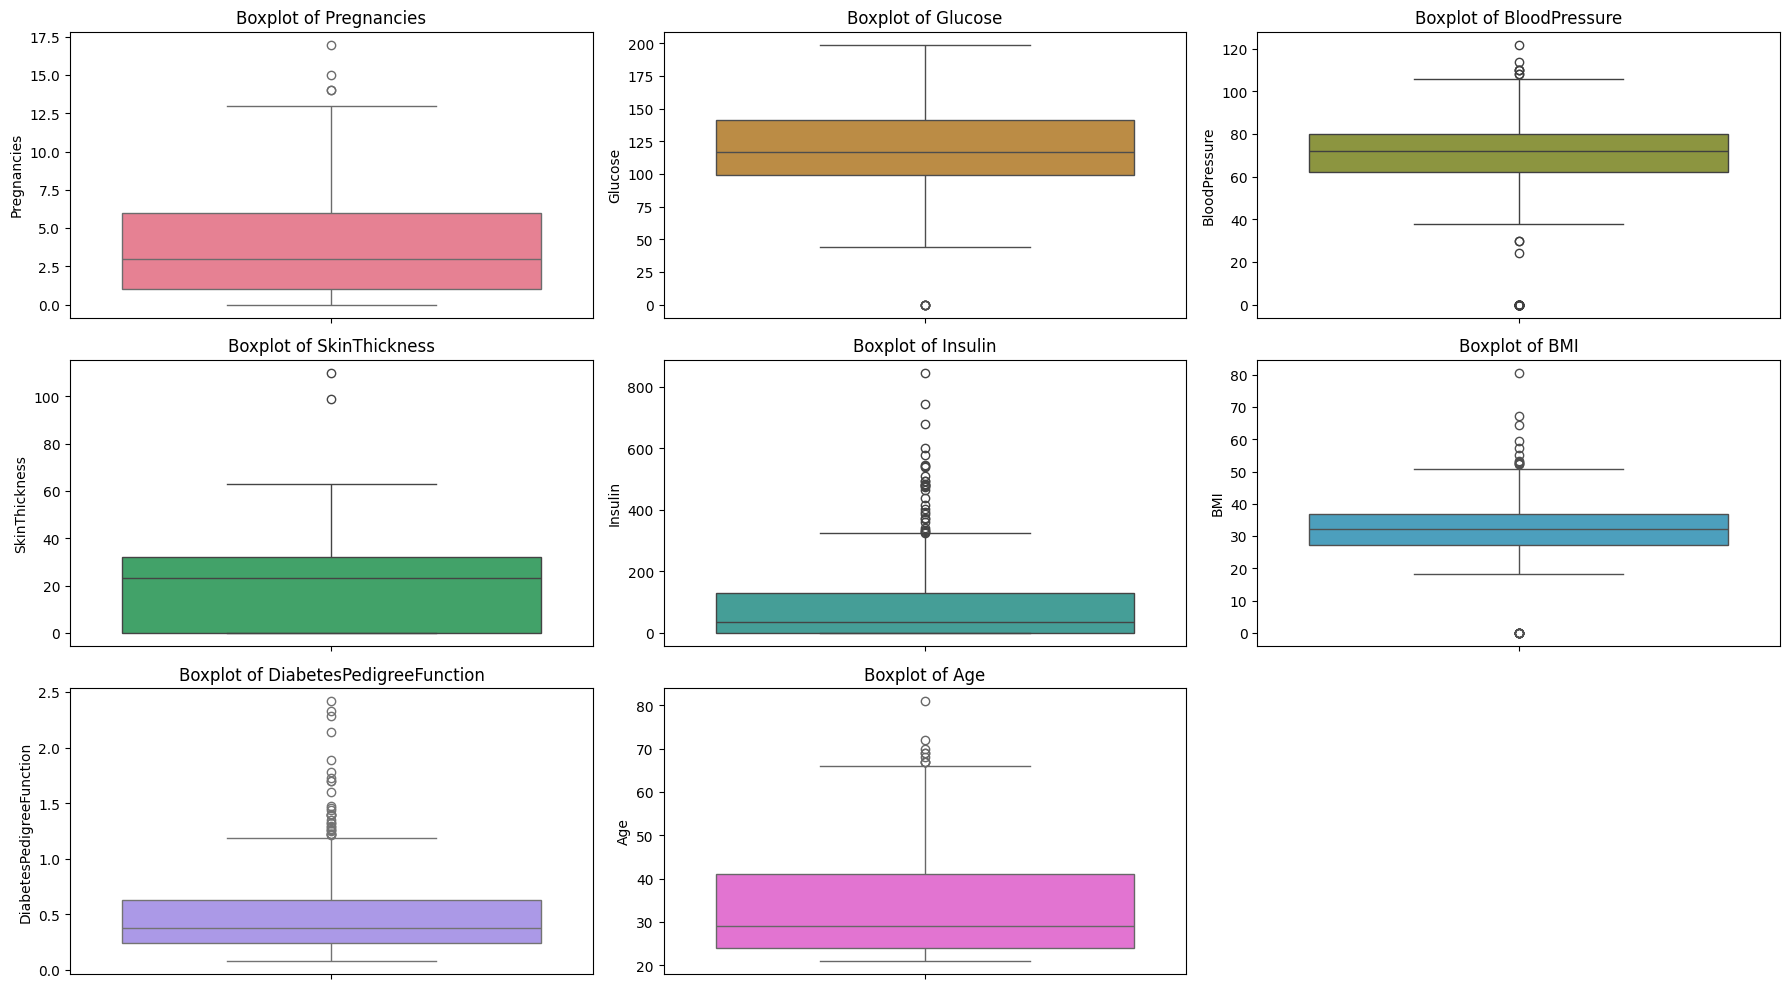

In [5]:
import math

numerical_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

palette = sns.color_palette("husl", len(numerical_cols))

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(18, 10))

for idx, (col, color) in enumerate(zip(numerical_cols, palette), 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.boxplot(y=df[col], color=color)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [6]:
print ("          Outliers in Columns comparison")
numerical_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers.count(),
        'Outlier %': (outliers.count() / len(df)) * 100
    })

outlier_table = pd.DataFrame(summary)

print (outlier_table) 

outlier_table ["Outlier Count"].describe()

total_rows = 2768
outlier_table["Outlier %"] = ((outlier_table["Outlier Count"] / total_rows) * 100).round(2)
outlier_table


          Outliers in Columns comparison
                     Column      Q1         Q3        IQR  Lower Bound  \
0               Pregnancies   1.000    6.00000    5.00000    -6.500000   
1                   Glucose  99.000  141.00000   42.00000    36.000000   
2             BloodPressure  62.000   80.00000   18.00000    35.000000   
3             SkinThickness   0.000   32.00000   32.00000   -48.000000   
4                   Insulin   0.000  130.00000  130.00000  -195.000000   
5                       BMI  27.325   36.77500    9.45000    13.150000   
6  DiabetesPedigreeFunction   0.244    0.62675    0.38275    -0.330125   
7                       Age  24.000   41.00000   17.00000    -1.500000   

   Upper Bound  Outlier Count  Outlier %  
0    13.500000              4   0.514139  
1   204.000000              5   0.642674  
2   107.000000             46   5.912596  
3    80.000000              2   0.257069  
4   325.000000             30   3.856041  
5    50.950000             22   2.

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Pregnancies,1.000,6.00000,5.00000,-6.500000,13.500000,4,0.14
1,Glucose,99.000,141.00000,42.00000,36.000000,204.000000,5,0.18
2,BloodPressure,62.000,80.00000,18.00000,35.000000,107.000000,46,1.66
3,SkinThickness,0.000,32.00000,32.00000,-48.000000,80.000000,2,0.07
4,Insulin,0.000,130.00000,130.00000,-195.000000,325.000000,30,1.08
5,BMI,27.325,36.77500,9.45000,13.150000,50.950000,22,0.79
6,DiabetesPedigreeFunction,0.244,0.62675,0.38275,-0.330125,1.200875,29,1.05
7,Age,24.000,41.00000,17.00000,-1.500000,66.500000,9,0.33


## Boostrap Test

In [7]:
import numpy as np

def outlier_percentage(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return ((series < lower) | (series > upper)).mean() * 100

col = "BloodPressure" 

boot_results = []

for _ in range(1000):
    sample = df[col].sample(frac=0.8, replace=True)
    boot_results.append(outlier_percentage(sample))

print(f"Original: {outlier_percentage(df[col]):.2f}%")
print(f"Bootstrap Mean: {np.mean(boot_results):.2f}%")
print(f"Std Dev: {np.std(boot_results):.2f}")
print ( )
print("Stability calculation" )
print (0.54 / 6.05)
print (" Stability: Blood Pressure consistent across resamples. The data outliers are likely population statistics ")

Original: 5.91%
Bootstrap Mean: 6.21%
Std Dev: 0.99

Stability calculation
0.08925619834710745
 Stability: Blood Pressure consistent across resamples. The data outliers are likely population statistics 


# Data Preparation 

In [8]:
df_md = df.copy()

cols_with_zero_issue = ['SkinThickness', 'Insulin']
df_md[cols_with_zero_issue] = df_md[cols_with_zero_issue].replace(0, np.nan)

df_md[cols_with_zero_issue] = df_md[cols_with_zero_issue].fillna(df_md.median())
df_md

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,126.0,33.6,0.627,50,1
1,1,85,66,29.0,126.0,26.6,0.351,31,0
2,8,183,64,29.0,126.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
2332,1,100,62,29.0,126.0,64.4,0.152,36,0
2333,0,163,40,23.0,64.0,40.7,0.322,33,0
2334,6,139,84,37.0,126.0,50.7,0.320,50,1
2335,2,167,44,30.0,140.0,52.7,0.452,28,0


In [9]:
df_md["Outcome"].value_counts()

Outcome
0    506
1    272
Name: count, dtype: int64

## KNN Imputer 

In [10]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_md), columns=df.columns)

In [11]:
df_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,126.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,126.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.0,126.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
773,1.0,100.0,62.0,29.0,126.0,64.4,0.152,36.0,0.0
774,0.0,163.0,40.0,23.0,64.0,40.7,0.322,33.0,0.0
775,6.0,139.0,84.0,37.0,126.0,50.7,0.320,50.0,1.0
776,2.0,167.0,44.0,30.0,140.0,52.7,0.452,28.0,0.0


# Models Analysis 

## XGBoost 

Resampled Train Accuracy: 0.796 | Train AUC: 0.869
Test Accuracy: 0.750 | Test AUC: 0.821

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       101
           1       0.63      0.71      0.67        55

    accuracy                           0.75       156
   macro avg       0.73      0.74      0.73       156
weighted avg       0.76      0.75      0.75       156



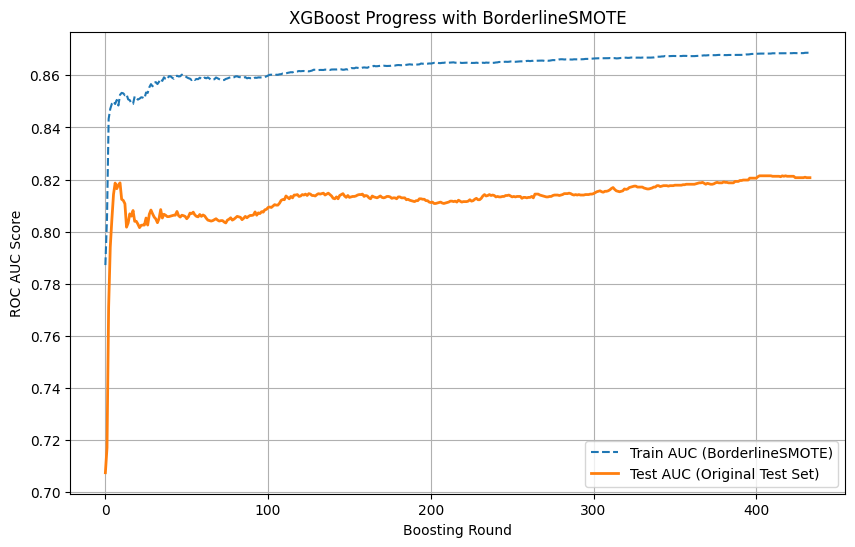

In [12]:
from imblearn.over_sampling import BorderlineSMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

X = df_md.drop(columns=['Outcome']) 
y = df_md['Outcome']

# Split the data (using 80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

bl_smote = BorderlineSMOTE(random_state=42, kind="borderline-1")
X_train_bl, y_train_bl = bl_smote.fit_resample(X_train, y_train)


model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,       
    max_depth=5,              
    min_child_weight=10,      
    gamma=3,                  
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=5,
    reg_lambda=5,
    early_stopping_rounds=10,
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train_bl, 
    y_train_bl,
    eval_set=[(X_train_bl, y_train_bl), (X_test, y_test)],
    verbose=False
)


y_train_pred = model.predict(X_train_bl)
y_test_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train_bl)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train_bl, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Resampled Train Accuracy: {accuracy_score(y_train_bl, y_train_pred):.3f} | Train AUC: {train_auc:.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f} | Test AUC: {test_auc:.3f}")
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))


results = model.evals_result()
train_auc_history = []
test_auc_history = []

for i in range(1, model.best_iteration + 1):
    y_train_p = model.predict_proba(X_train_bl, iteration_range=(0, i))[:, 1]
    y_test_p = model.predict_proba(X_test, iteration_range=(0, i))[:, 1]
    train_auc_history.append(roc_auc_score(y_train_bl, y_train_p))
    test_auc_history.append(roc_auc_score(y_test, y_test_p))

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_auc_history, label='Train AUC (BorderlineSMOTE)', linestyle='--')
plt.plot(test_auc_history, label='Test AUC (Original Test Set)', linewidth=2)
plt.xlabel('Boosting Round')
plt.ylabel('ROC AUC Score')
plt.title('XGBoost Progress with BorderlineSMOTE')
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance 

                    Feature  Importance
5                       BMI    0.254372
1                   Glucose    0.194070
7                       Age    0.139553
4                   Insulin    0.112512
6  DiabetesPedigreeFunction    0.097360
3             SkinThickness    0.089526
2             BloodPressure    0.059072
0               Pregnancies    0.053535


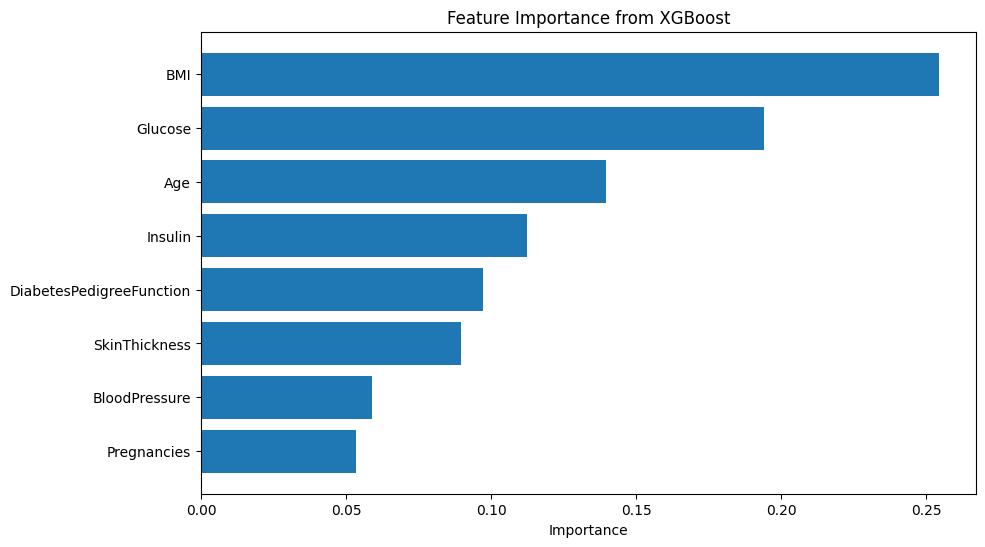

In [13]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Importance')
plt.title('Feature Importance from XGBoost')
plt.show()

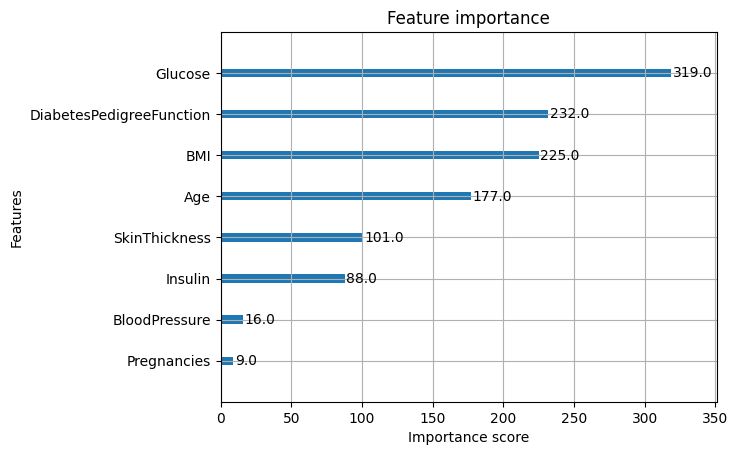

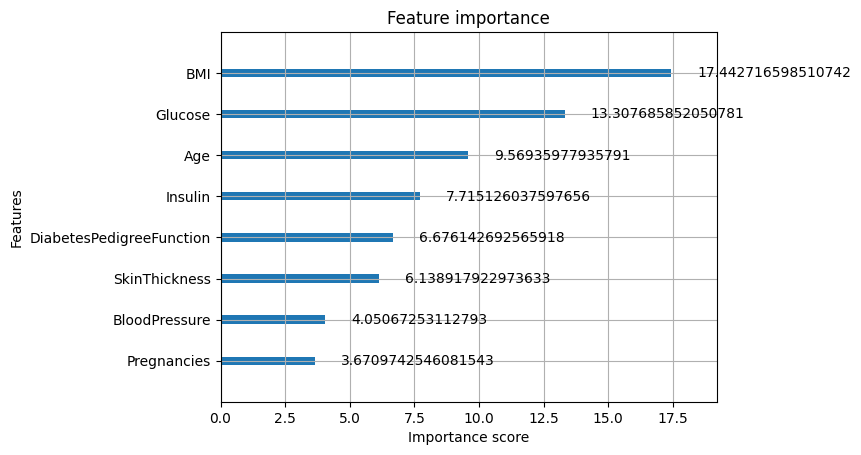

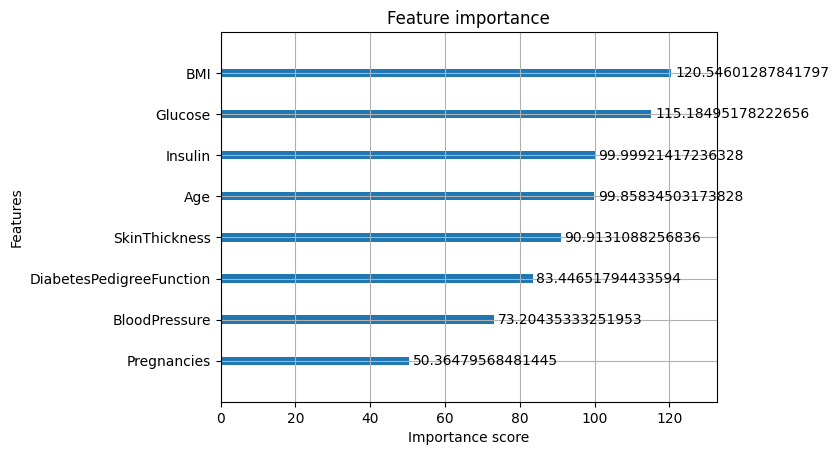

In [14]:
xgb.plot_importance(model, importance_type='weight', max_num_features=10)
plt.show()

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.show()

xgb.plot_importance(model, importance_type='cover', max_num_features=10)
plt.show()

### Partial Dependancy Analysis 

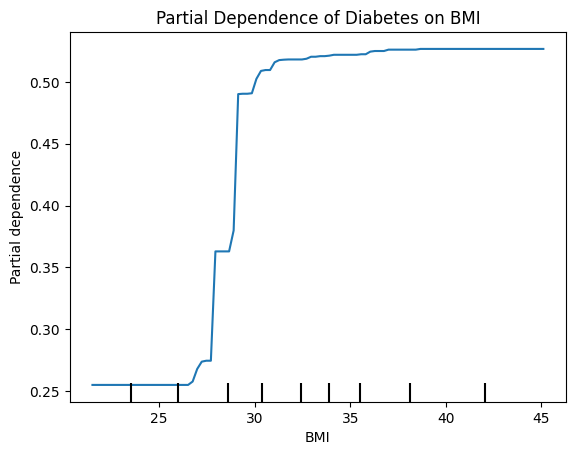

In [15]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=['BMI'],
    grid_resolution=100,
)
plt.title("Partial Dependence of Diabetes on BMI")
plt.show()

### Cumulative Gain

In [16]:
importance_dict = {
    'Glucose': 0.233879,
    'BMI': 0.139532,
    'Age': 0.135903,
    'Pregnancies': 0.106474,
    'Insulin': 0.103932,
    'DiabetesPedigreeFunction': 0.098567,
    'BloodPressure': 0.092960,
    'SkinThickness': 0.088754
}

feat_imp = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

feat_imp = feat_imp.sort_values(by='Gain', ascending=False)

# Cumulative gain
feat_imp['CumulativeGain'] = feat_imp['Gain'].cumsum()
feat_imp['CumulativeGain%'] = feat_imp['CumulativeGain'] / feat_imp['Gain'].sum() * 100

print(feat_imp)

                    Feature      Gain  CumulativeGain  CumulativeGain%
0                   Glucose  0.233879        0.233879        23.387877
1                       BMI  0.139532        0.373411        37.341063
2                       Age  0.135903        0.509314        50.931349
3               Pregnancies  0.106474        0.615788        61.578738
4                   Insulin  0.103932        0.719720        71.971928
5  DiabetesPedigreeFunction  0.098567        0.818287        81.828618
6             BloodPressure  0.092960        0.911247        91.124609
7             SkinThickness  0.088754        1.000001       100.000000


## Random Forest

In [17]:
df_rf = df.copy()

df_rf = df_rf.drop_duplicates()

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']
df_rf[cols_to_fix] = df_rf[cols_to_fix].replace(0, np.nan)

X_rf = df_rf.drop(columns=['Outcome'])
y_rf = df_rf['Outcome']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

print("Training shape:", X_train_rf.shape)
print("Test shape:", X_test_rf.shape)
print("\nTarget distribution:")
print(y_rf.value_counts())

Training shape: (622, 8)
Test shape: (156, 8)

Target distribution:
Outcome
0    506
1    272
Name: count, dtype: int64


In [18]:
rf_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', BorderlineSMOTE(random_state=42, kind='borderline-1')),
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', BorderlineSMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

### Cross Validation

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_rf = cross_validate(
    rf_pipeline,
    X_train_rf,
    y_train_rf,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'],
    n_jobs=-1,
    return_train_score=False
)

print("Random Forest + Borderline-SMOTE Cross-Validation Results")
print("--------------------------------------------------------")
print(f"Mean Accuracy:  {cv_results_rf['test_accuracy'].mean():.4f}")
print(f"Mean ROC-AUC:   {cv_results_rf['test_roc_auc'].mean():.4f}")
print(f"Mean Precision: {cv_results_rf['test_precision'].mean():.4f}")
print(f"Mean Recall:    {cv_results_rf['test_recall'].mean():.4f}")
print(f"Mean F1:        {cv_results_rf['test_f1'].mean():.4f}")

Random Forest + Borderline-SMOTE Cross-Validation Results
--------------------------------------------------------
Mean Accuracy:  0.7395
Mean ROC-AUC:   0.8092
Mean Precision: 0.6129
Mean Recall:    0.6909
Mean F1:        0.6480


In [20]:
rf_pipeline.fit(X_train_rf, y_train_rf)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', BorderlineSMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


Random Forest Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       101
           1       0.65      0.71      0.68        55

    accuracy                           0.76       156
   macro avg       0.74      0.75      0.75       156
weighted avg       0.77      0.76      0.76       156

Accuracy:      0.7628
ROC-AUC Score: 0.8318
Confusion Matrix:
[[80 21]
 [16 39]]


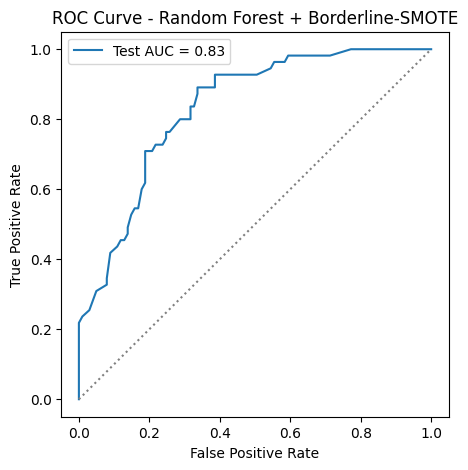

In [21]:
y_pred_rf = rf_pipeline.predict(X_test_rf)
y_proba_rf = rf_pipeline.predict_proba(X_test_rf)[:, 1]

print("\n" + "="*25)
print("Random Forest Report")
print("="*25)
print(classification_report(y_test_rf, y_pred_rf))
print(f"Accuracy:      {accuracy_score(y_test_rf, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_rf, y_proba_rf):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))

fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test_rf, y_proba_rf)
test_auc_rf = roc_auc_score(y_test_rf, y_proba_rf)

plt.figure(figsize=(5, 5))
plt.plot(fpr_test_rf, tpr_test_rf, label=f'Test AUC = {test_auc_rf:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.title('ROC Curve - Random Forest + Borderline-SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Best Parameters estimation

In [22]:
param_dist_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [3, 5, 7, 10, None],
    'rf__min_samples_split': [2, 5, 10, 15],
    'rf__min_samples_leaf': [1, 2, 4, 6],
    'rf__max_features': ['sqrt', 0.5, 0.75],
    'rf__max_samples': [0.6, 0.8, None],
    'rf__class_weight': [None, 'balanced']
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_rf, y_train_rf)

print("Best Parameters:")
print(rf_random_search.best_params_)
print(f"\nBest CV ROC-AUC: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'rf__n_estimators': 200, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 4, 'rf__max_samples': None, 'rf__max_features': 'sqrt', 'rf__max_depth': 3, 'rf__class_weight': None}

Best CV ROC-AUC: 0.8155


In [23]:
best_rf_model = rf_random_search.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test_rf)
y_proba_rf_tuned = best_rf_model.predict_proba(X_test_rf)[:, 1]

print("\n" + "="*30)
print("Tuned Random Forest Report")
print("="*30)
print(classification_report(y_test_rf, y_pred_rf_tuned))
print(f"Accuracy:      {accuracy_score(y_test_rf, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_rf, y_proba_rf_tuned):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf_tuned))


Tuned Random Forest Report
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       101
           1       0.62      0.87      0.73        55

    accuracy                           0.77       156
   macro avg       0.77      0.79      0.76       156
weighted avg       0.81      0.77      0.77       156

Accuracy:      0.7692
ROC-AUC Score: 0.8599
Confusion Matrix:
[[72 29]
 [ 7 48]]


### ROC Analysis

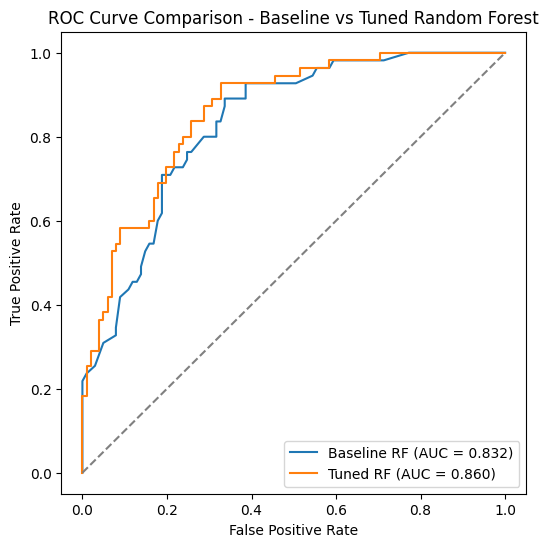

In [24]:
fpr_base, tpr_base, _ = roc_curve(y_test_rf, y_proba_rf)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test_rf, y_proba_rf_tuned)

auc_base = roc_auc_score(y_test_rf, y_proba_rf)
auc_tuned = roc_auc_score(y_test_rf, y_proba_rf_tuned)

plt.figure(figsize=(6, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline RF (AUC = {auc_base:.3f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned RF (AUC = {auc_tuned:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Baseline vs Tuned Random Forest')
plt.legend(loc='lower right')
plt.show()

### Feature Importance

In [25]:
rf_final = best_rf_model.named_steps['rf']

feature_importance_df_rf = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_df_rf

,Feature,Importance
1,Glucose,0.323885
5,BMI,0.226878
7,Age,0.148580
4,Insulin,0.095863
3,SkinThickness,0.071256
6,DiabetesPedigreeFunction,0.057127
0,Pregnancies,0.054557
2,BloodPressure,0.021855


## Permutation Importance

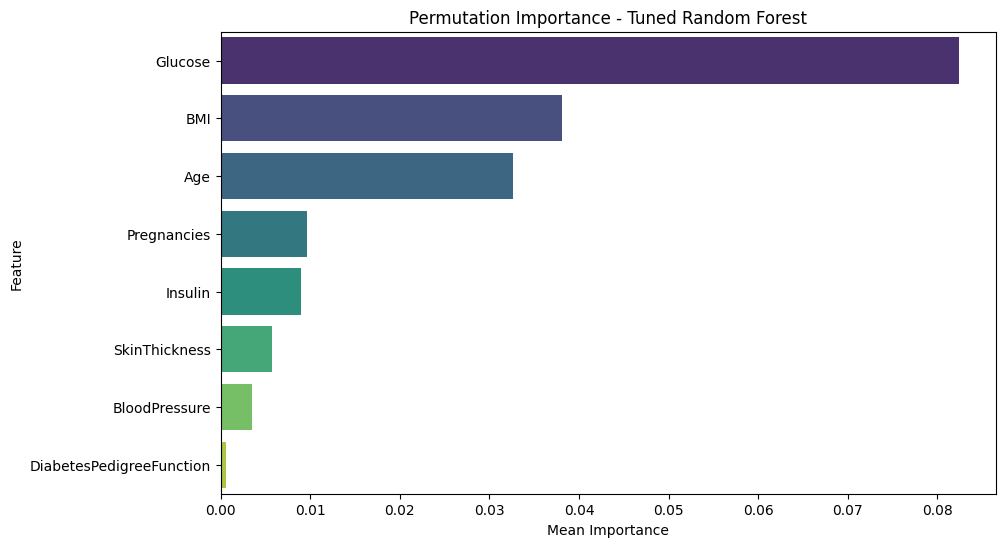

In [26]:
perm = permutation_importance(
    best_rf_model,
    X_test_rf,
    y_test_rf,
    n_repeats=20,
    random_state=42
)

perm_df_rf = pd.DataFrame({
    'Feature': X_rf.columns,
    'Mean Importance': perm.importances_mean,
    'Std Importance': perm.importances_std
}).sort_values(by='Mean Importance', ascending=False)

perm_df_rf

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df_rf, x='Mean Importance', y='Feature', palette='viridis')
plt.title('Permutation Importance - Tuned Random Forest')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

## Performance as trees increase 

In [27]:

best_params_rf = rf_random_search.best_params_

tree_counts = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

for n in range(10, 301, 10):
    temp_pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', BorderlineSMOTE(random_state=42, kind='borderline-1')),
        ('rf', RandomForestClassifier(
            n_estimators=n,
            max_depth=best_params_rf.get('rf__max_depth', None),
            min_samples_split=best_params_rf.get('rf__min_samples_split', 2),
            min_samples_leaf=best_params_rf.get('rf__min_samples_leaf', 1),
            max_features=best_params_rf.get('rf__max_features', 'sqrt'),
            max_samples=best_params_rf.get('rf__max_samples', None),
            class_weight=best_params_rf.get('rf__class_weight', None),
            random_state=42
        ))
    ])

    temp_pipeline.fit(X_train_rf, y_train_rf)
    y_pred_temp = temp_pipeline.predict(X_test_rf)
    y_proba_temp = temp_pipeline.predict_proba(X_test_rf)[:, 1]

    tree_counts.append(n)
    accuracy_scores.append(accuracy_score(y_test_rf, y_pred_temp))
    precision_scores.append(precision_score(y_test_rf, y_pred_temp))
    recall_scores.append(recall_score(y_test_rf, y_pred_temp))
    f1_scores.append(f1_score(y_test_rf, y_pred_temp))
    auc_scores.append(roc_auc_score(y_test_rf, y_proba_temp))

In [28]:
# tree growth metrics table

tree_metrics_df_rf = pd.DataFrame({
    'Number of Trees': tree_counts,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores,
    'ROC-AUC': auc_scores
})

tree_metrics_df_rf.head()

,Number of Trees,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,10,0.756410,0.616438,0.818182,0.703125,0.854545
1,20,0.756410,0.607595,0.872727,0.716418,0.862106
2,30,0.762821,0.615385,0.872727,0.721805,0.860486
3,40,0.769231,0.623377,0.872727,0.727273,0.861926
4,50,0.762821,0.618421,0.854545,0.717557,0.855626


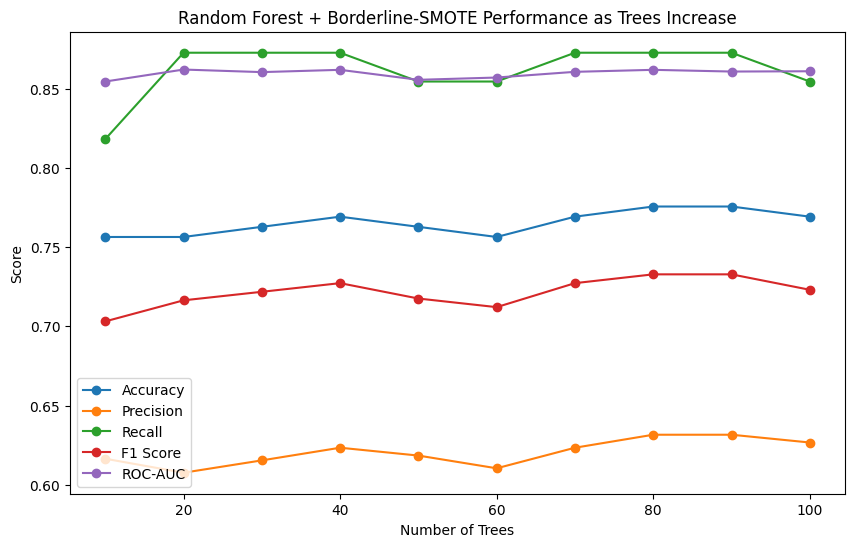

In [29]:
# tree growth plot

plot_df = tree_metrics_df_rf[tree_metrics_df_rf['Number of Trees'] <= 100]

plt.figure(figsize=(10, 6))

plt.plot(plot_df['Number of Trees'], plot_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(plot_df['Number of Trees'], plot_df['Precision'], marker='o', label='Precision')
plt.plot(plot_df['Number of Trees'], plot_df['Recall'], marker='o', label='Recall')
plt.plot(plot_df['Number of Trees'], plot_df['F1 Score'], marker='o', label='F1 Score')
plt.plot(plot_df['Number of Trees'], plot_df['ROC-AUC'], marker='o', label='ROC-AUC')

plt.xlabel("Number of Trees")
plt.ylabel("Score")
plt.title("Random Forest + Borderline-SMOTE Performance as Trees Increase")
plt.legend()
plt.show()

## Logistic Regression 

In [30]:

df = df.drop_duplicates()

df_reduced = df.copy()
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']
df_reduced[cols_to_fix] = df_reduced[cols_to_fix].replace(0, np.nan)
X = df_reduced.drop(columns=['Outcome'])
y = df_reduced['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:

def rename_columns(X_array):
    return pd.DataFrame(X_array, columns=X_train.columns)
log_cols = ['Pregnancies', 'SkinThickness', 'DiabetesPedigreeFunction', 'Age', 'Insulin']
other_cols = ['Glucose', 'BloodPressure', 'BMI']

preprocessor = ColumnTransformer(
    transformers=[
        ('log_transform', FunctionTransformer(np.log1p), log_cols),
        ('pass', 'passthrough', other_cols)
    ]
)

lr_model = Pipeline([
    ('imputer', IterativeImputer(random_state=42, min_value=0)),
    ('relabel', FunctionTransformer(rename_columns)), 
    ('log_step', preprocessor),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1, max_iter=1000, class_weight='balanced', random_state=42))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', IterativeImputer(min_value=0, random_state=42)),
                ('relabel',
                 FunctionTransformer(func=<function rename_columns at 0x7f0e3144d3a0>)),
                ('log_step',
                 ColumnTransformer(transformers=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Pregnancies',
                                                   'SkinThickness',
                                                   'DiabetesPedigreeFunction',
                                                   'Age', 'Insulin']),
                                                 ('pass', 'passthrough',
                                                  ['Glucose', 'BloodPressure',
                                                   'BMI'])])),
                ('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### Model evaluation

In [32]:
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]


print("\n" + "="*20)
print("  Logistic Regression Report")
print("="*20)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\n" + "="*20)
print("  Feature Coefficients")
print("="*20)
feature_names = log_cols + other_cols
coefs = lr_model.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs}).sort_values(by='Coefficient', ascending=False)
print(coef_df.to_string(index=False))


print("Confusion Matrix:" )
print(confusion_matrix(y_test, y_pred))


  Logistic Regression Report
              precision    recall  f1-score   support

           0       0.84      0.75      0.80       101
           1       0.62      0.75      0.68        55

    accuracy                           0.75       156
   macro avg       0.73      0.75      0.74       156
weighted avg       0.77      0.75      0.75       156

ROC-AUC Score: 0.8180

  Feature Coefficients
                 Feature  Coefficient
                 Glucose     0.975122
                     BMI     0.532133
DiabetesPedigreeFunction     0.309672
             Pregnancies     0.251787
                     Age     0.239024
                 Insulin     0.210444
           SkinThickness     0.104739
           BloodPressure    -0.003218
Confusion Matrix:
[[76 25]
 [14 41]]


### Hyperparameter tuning

In [33]:
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear'] 
}

grid_search = GridSearchCV(lr_model, param_grid, cv=5, scoring='roc_auc', verbose=1)

print("--- Start to tune hyperparameters ---")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

lr_model = grid_search.best_estimator_

--- Start to tune hyperparameters ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'lr__C': 10, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
Best Cross-Validation AUC: 0.8382


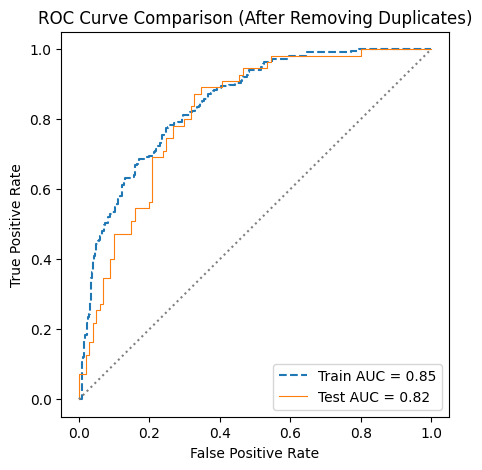

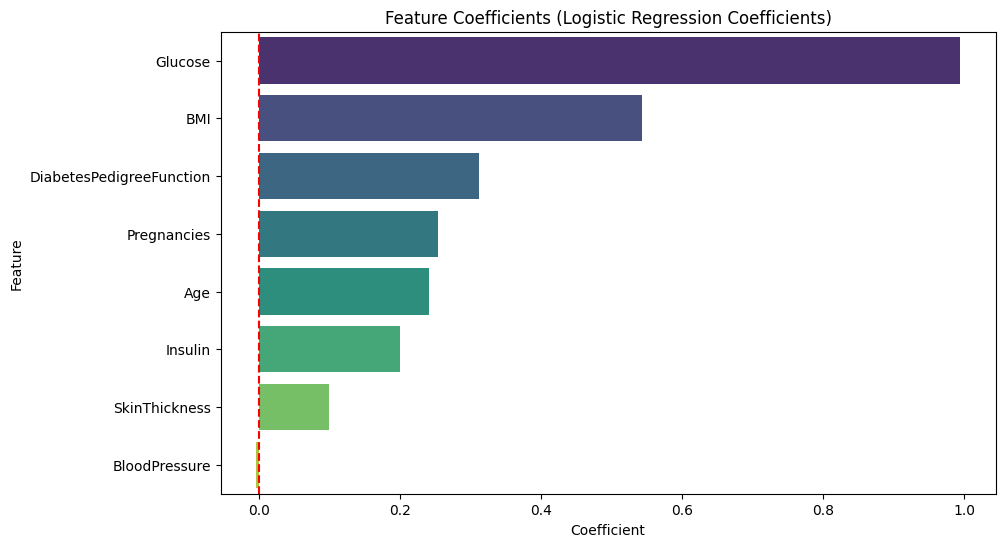

In [34]:
y_train_proba = lr_model.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc(fpr_train, tpr_train):.2f}', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc(fpr_test, tpr_test):.2f}', lw=0.8)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.title('ROC Curve Comparison (After Removing Duplicates)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

feature_names = log_cols + other_cols 
coefs = lr_model.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Feature Coefficients (Logistic Regression Coefficients)')
plt.show()




In [35]:
bsmote = BorderlineSMOTE(random_state=42, kind='borderline-1')

log_cols = ['Pregnancies', 'SkinThickness', 'DiabetesPedigreeFunction', 'Age', 'Insulin']
other_cols = ['Glucose', 'BloodPressure', 'BMI']  

preprocessor = ColumnTransformer(
    transformers=[
        ('log_transform', FunctionTransformer(np.log1p), log_cols)
    ],
    remainder='passthrough', 
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

it_imputer = IterativeImputer(random_state=42)
it_imputer.set_output(transform="pandas")

final_pipeline = ImbPipeline([
    ('imputer', it_imputer),         
    ('log_step', preprocessor),     
    ('smote', BorderlineSMOTE(random_state=42, kind='borderline-1')), 
    ('scaler', StandardScaler()),     
    ('final_fix', SimpleImputer(strategy='median')),
    ('lr', LogisticRegression(C=10, max_iter=1000, penalty='l1', class_weight='balanced', random_state=42, solver='liblinear'))
])

final_pipeline.fit(X_train, y_train)

y_pred_f = final_pipeline.predict(X_test)
y_proba_f = final_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Optimized Evaluation Report ---")
print(classification_report(y_test, y_pred_f))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_proba_f):.4f}")


print("Confusion Matrix:" )
print(confusion_matrix(y_test, y_pred_f))


--- Optimized Evaluation Report ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.78       101
           1       0.59      0.80      0.68        55

    accuracy                           0.74       156
   macro avg       0.73      0.75      0.73       156
weighted avg       0.77      0.74      0.74       156

Final ROC-AUC Score: 0.8243
Confusion Matrix:
[[71 30]
 [11 44]]


### ROC evaulation

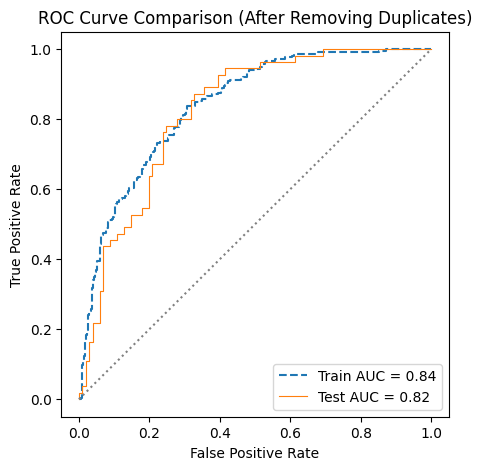

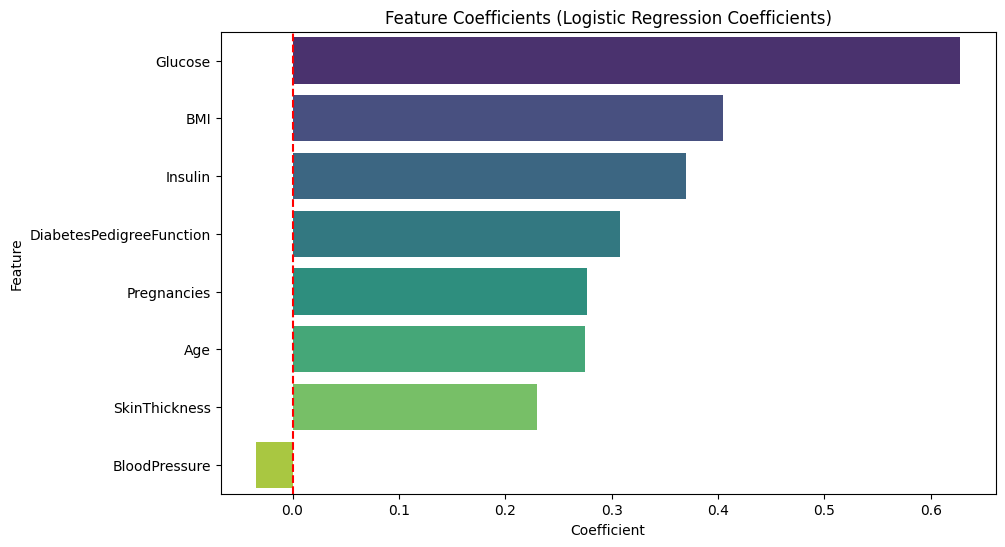

In [36]:
y_train_proba = final_pipeline.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_f)

plt.figure(figsize=(5, 5))
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc(fpr_train, tpr_train):.2f}', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc(fpr_test, tpr_test):.2f}', lw=0.8)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.title('ROC Curve Comparison (After Removing Duplicates)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

feature_names = log_cols + other_cols 
coefs = final_pipeline.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Feature Coefficients (Logistic Regression Coefficients)')
plt.show()

In [37]:
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]

print("\n--- Optimized Evaluation Report ---")
print(classification_report(y_test, y_pred))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


print("Confusion Matrix:" )
print(confusion_matrix(y_test, y_pred))


--- Optimized Evaluation Report ---
              precision    recall  f1-score   support

           0       0.84      0.75      0.80       101
           1       0.62      0.75      0.68        55

    accuracy                           0.75       156
   macro avg       0.73      0.75      0.74       156
weighted avg       0.77      0.75      0.75       156

Final ROC-AUC Score: 0.8182
Confusion Matrix:
[[76 25]
 [14 41]]


# Models Comparison 

In [38]:
# comparison table for al of the models

comparison_all_models = pd.DataFrame({
    'Model': [
        'Logistic Regression + Borderline-SMOTE',
        'XGBoost + Borderline-SMOTE',
        'Tuned Random Forest + Borderline-SMOTE'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_f),
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test_rf, y_pred_rf_tuned)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_f),
        roc_auc_score(y_test, y_test_proba),
        roc_auc_score(y_test_rf, y_proba_rf_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_f),
        precision_score(y_test, y_test_pred),
        precision_score(y_test_rf, y_pred_rf_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_f),
        recall_score(y_test, y_test_pred),
        recall_score(y_test_rf, y_pred_rf_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_f),
        f1_score(y_test, y_test_pred),
        f1_score(y_test_rf, y_pred_rf_tuned)
    ]

})

comparison_all_models

,Model,Accuracy,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression + Borderline-SMOTE,0.737179,0.824302,0.594595,0.800000,0.682171
1,XGBoost + Borderline-SMOTE,0.750000,0.820702,0.629032,0.709091,0.666667
2,Tuned Random Forest + Borderline-SMOTE,0.769231,0.859946,0.623377,0.872727,0.727273


# DATABASE - practical application 

import sqlite3
import hashlib
from cryptography.fernet import Fernet

 --- SETUP ---
KEY = b'u76_X_D7-6O8_qX7Z_X76_X76_X76_X76_X76_X76_X=' 
cipher = Fernet(KEY)

def get_hash(text):
    return hashlib.sha256(text.lower().strip().encode()).hexdigest()

def get_connection():
    conn = sqlite3.connect('hospital_space.db')
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS patient_records (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            name_hash TEXT UNIQUE, 
            name_enc TEXT,
            glucose REAL,
            bmi REAL,
            age INTEGER,
            risk_label_enc TEXT
        )
    ''')
    return conn

def add_patient_ui():
    name = input("Enter Patient Name: ").strip()
    glucose = float(input("Glucose: "))
    bmi = float(input("BMI: "))
    age = int(input("Age: "))

    # --- NEW UPDATED LOGIC ---
    # Calculate how many risk factors are present
    risk_score = int(glucose > 120) + int(bmi > 25) + int(age > 50)

    if risk_score == 3:
        risk = "High Risk"
    elif risk_score == 2:
        risk = "Medium - Consider Check up"
    else:
        risk = "Low Risk"
    # -------------------------
    
    # Security
    n_hash = get_hash(name)
    n_enc = cipher.encrypt(name.encode()).decode()
    r_enc = cipher.encrypt(risk.encode()).decode()

    conn = get_connection()
    try:
        conn.execute("INSERT INTO patient_records (name_hash, name_enc, glucose, bmi, age, risk_label_enc) VALUES (?,?,?,?,?,?)",
                     (n_hash, n_enc, glucose, bmi, age, r_enc))
        conn.commit()
        print(f"Success: {name} added as '{risk}'.")
    except sqlite3.IntegrityError:
        print("Error: This patient already exists.")
    finally:
        conn.close()

def search_patient_ui():
    name_query = input("Search Name: ").strip()
    target_hash = get_hash(name_query)

    conn = get_connection()
    cursor = conn.cursor()
    
    cursor.execute("SELECT name_enc, glucose, bmi, age, risk_label_enc FROM patient_records WHERE name_hash = ?", (target_hash,))
    row = cursor.fetchone()
    
    if row:
        name = cipher.decrypt(row[0].encode()).decode()
        risk = cipher.decrypt(row[4].encode()).decode()
        print(f"\nFound: {name} | Risk: {risk} | G:{row[1]} B:{row[2]} A:{row[3]}")
    else:
        print("No patient found.")
    conn.close()

- Main Menu
while True:
    choice = input("\n1. Add  2. Search  3. Exit: ")
    if choice == '1': add_patient_ui()
    elif choice == '2': search_patient_ui()
    elif choice == '3': break

jsbsj
